# TP 3 - Parte 1

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import util_cb as utils
import supervision as sv

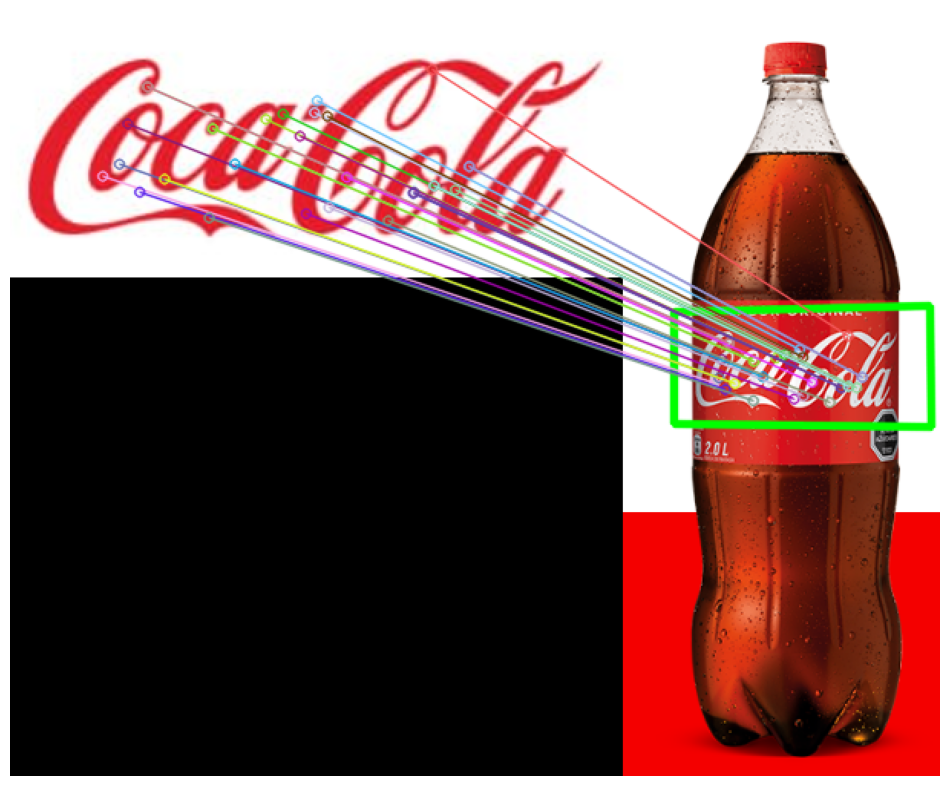

In [2]:
template_raw, template_proc, crop_xy = utils.load_and_preprocess_template("material/template/pattern.png", invert=True, equalize=True)
target_raw, target_proc = utils.preprocess_target("material/images/coca_logo_1.png", invert=False, equalize=True)

kp1, des1 = utils.find_kp_and_des(template_proc)
kp2, des2 = utils.find_kp_and_des(target_proc)

utils.match_and_show_2(template_raw, crop_xy, target_raw, kp1, des1, kp2, des2)

Cargar imágenes

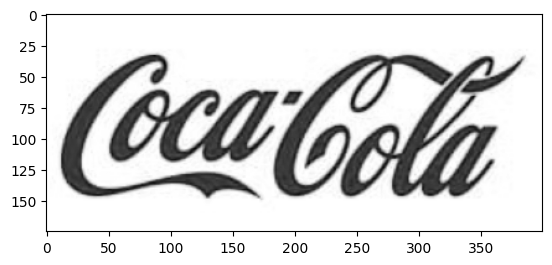

In [3]:
template_raw = cv.imread('material/template/pattern.png', cv.IMREAD_GRAYSCALE)
plt.imshow(template_raw, cmap='gray')

Recortaré la imágen para eliminar los márgenes innecesarios. Para ello convertiré la imágen en blanco y negro estricto y luego la invertiré. Al final me quedaré con el área que encierra pixeles blancos

Acá se podría probar cv.findContours() para qué busque solo el contorno

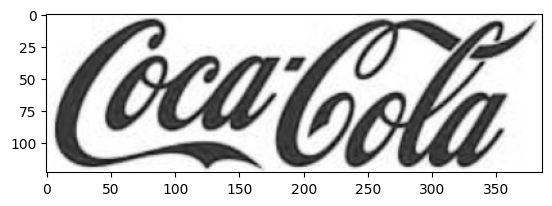

In [4]:
_, thresh = cv.threshold(template_raw, 250, 255, cv.THRESH_BINARY_INV)
x, y, w, h = cv.boundingRect(thresh)
template_cropped = template_raw[y:y+h, x:x+w]

plt.imshow(template_cropped, cmap='gray')

Invierto el template

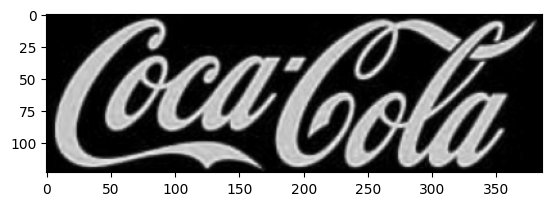

In [5]:
template = 255 - template_cropped
# template = template_cropped

plt.imshow(template, cmap='gray')

Uso Clahe para mejorar los bordes.

Acá podríamos usar unmask sharping ? 

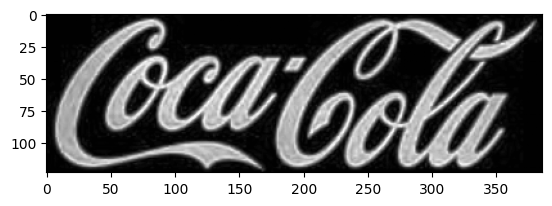

In [6]:
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
template = clahe.apply(template)

plt.imshow(template, cmap='gray')

Agrego todo el preprocesamiento del target

In [7]:
def preprocess_target(path, invert=False):
    target_raw = cv.imread(path, cv.IMREAD_GRAYSCALE)
    assert target_raw is not None, "Error al cargar target."
    target_invert = target_raw if not invert else 255 - target_raw
    target_sharp = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(target_invert)
    return target_sharp

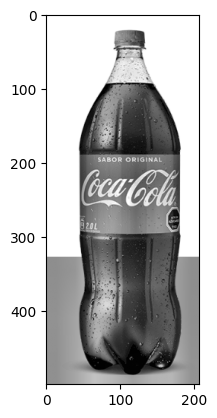

In [8]:
target = preprocess_target('material/images/coca_logo_1.png')
plt.imshow(target, cmap='gray')

Pruebo SIFT porque es el que mejor resultados me dió

Acá podríamos probar otros algorítmos

In [9]:
def find_kp_and_des(img):
    return cv.SIFT_create().detectAndCompute(img, None)

In [10]:
kp1, des1 = find_kp_and_des(template)
kp2, des2 = find_kp_and_des(target)

In [11]:
def match_and_show(kp1, kp2, des1, des2, target):

    bf = cv.BFMatcher(cv.NORM_L2)
    matches = bf.knnMatch(des1, des2, k=2)
    
    # Lowe test
    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)
    
    # ----------- Intentar homografía con matches buenos -----------
    MIN_MATCH_COUNT = 4
    img_color = cv.cvtColor(target, cv.COLOR_GRAY2BGR)
    
    if len(good) >= MIN_MATCH_COUNT:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        if M is not None:
            matchesMask = mask.ravel().tolist()
            good_inliers = [m for i, m in enumerate(good) if matchesMask[i]]
    
            # Proyectar el área del patrón sobre la imagen destino
            h_t, w_t = template.shape
            box = np.float32([[0,0], [0,h_t], [w_t,h_t], [w_t,0]]).reshape(-1,1,2)
            projected = cv.perspectiveTransform(box, M)
            cv.polylines(img_color, [np.int32(projected)], True, (0, 255, 0), 3, cv.LINE_AA)
        else:
            print("No se pudo estimar homografía.")
            good_inliers = []
    else:
        print(f"Insuficientes matches válidos: {len(good)} / {MIN_MATCH_COUNT}")
        good_inliers = []
    
    # ----------- Dibujar solo los inliers -----------
    draw_params = dict(matchColor=(0, 255, 0),
                       singlePointColor=None,
                       matchesMask=None,
                       flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    img_out = cv.drawMatches(template, kp1, img_color, kp2, good_inliers, None, **draw_params)
    
    # ----------- Mostrar resultado -----------
    plt.figure(figsize=(12, 6))
    plt.imshow(img_out)
    plt.title(f"Matches buenos (inliers): {len(good_inliers)}")
    plt.axis('off')
    plt.show()

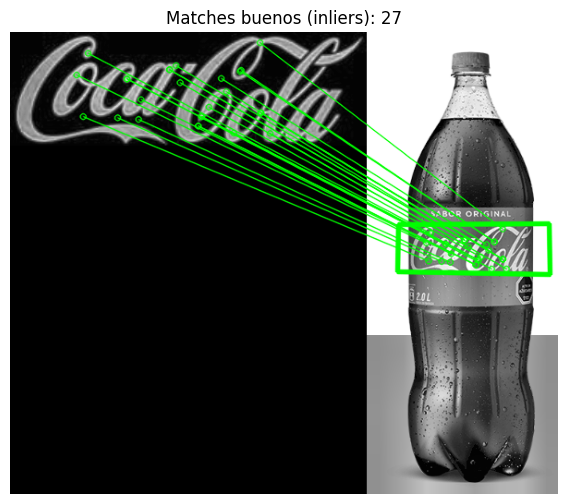

In [12]:
match_and_show(kp1, kp2, des1, des2, target)

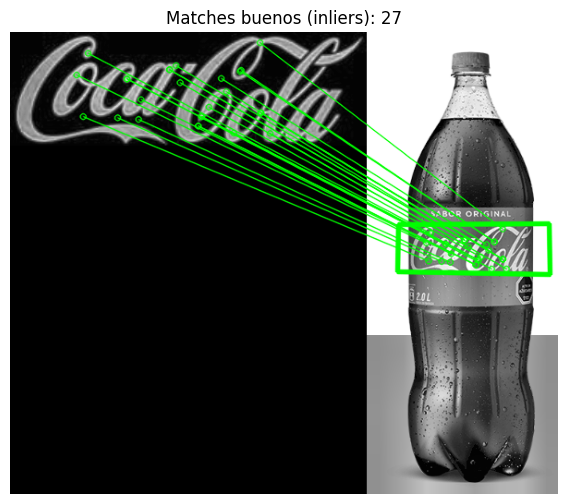

In [13]:
logo = preprocess_target("material/images/coca_logo_1.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

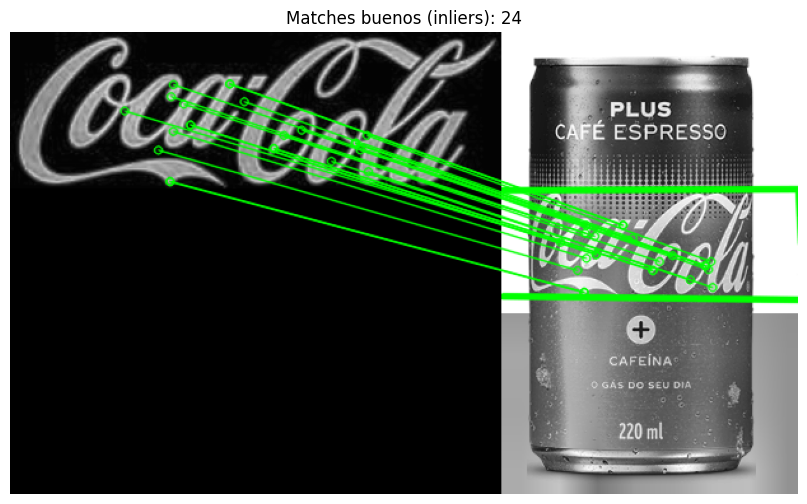

In [14]:
logo = preprocess_target("material/images/coca_logo_2.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

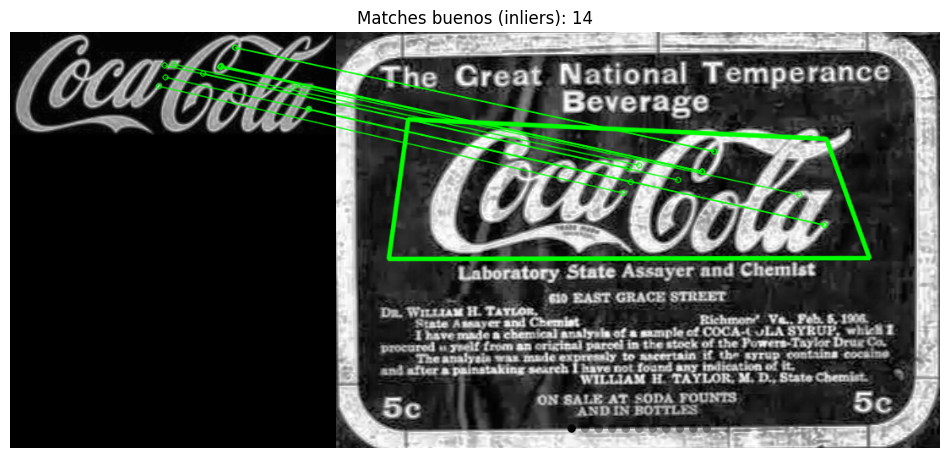

In [15]:
logo = preprocess_target("material/images/coca_retro_1.png", invert=True)
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

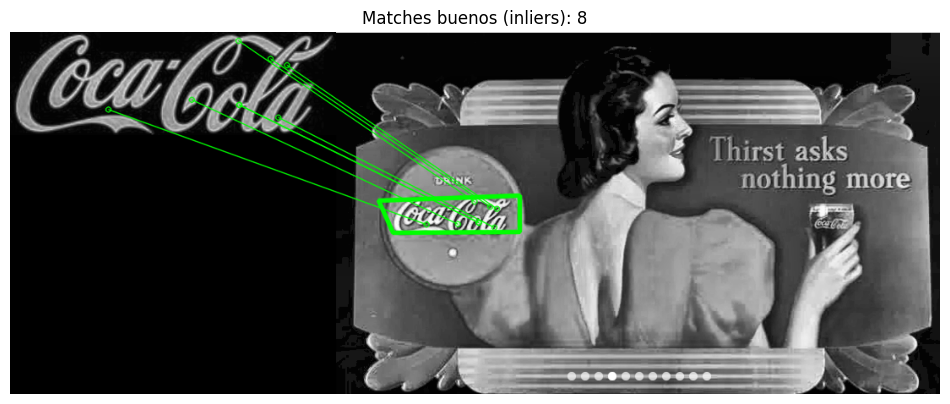

In [16]:
logo = preprocess_target("material/images/coca_retro_2.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

Este no salió 

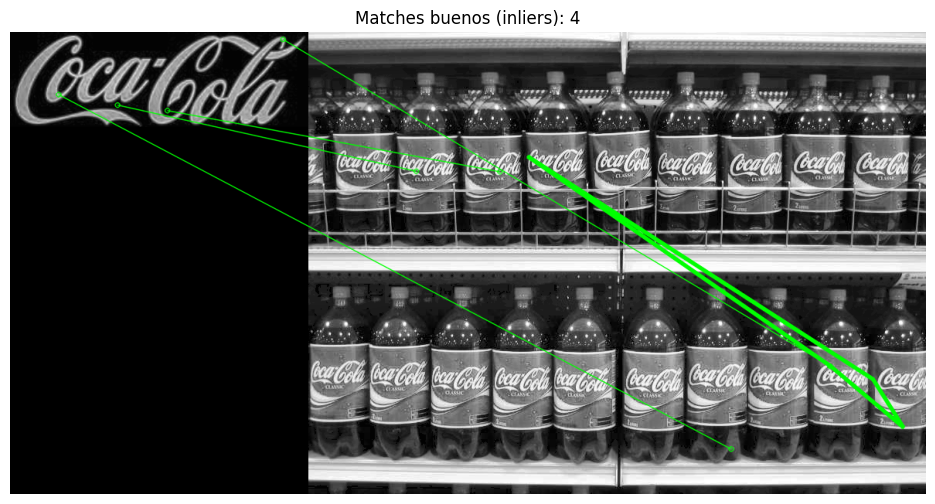

In [17]:
logo = preprocess_target("material/images/coca_multi.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

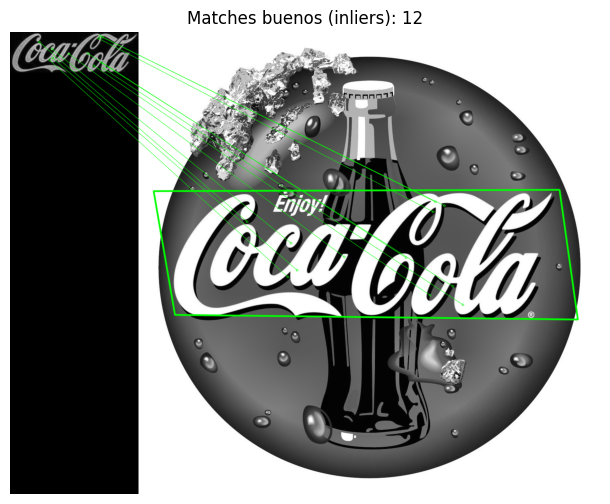

In [18]:
logo = preprocess_target("material/images/COCA-COLA-LOGO.jpg")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

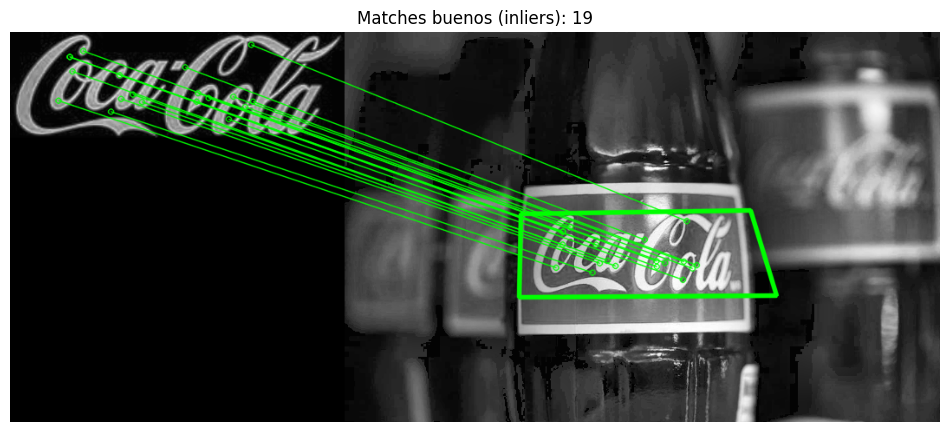

In [19]:
logo = preprocess_target("material/images/logo_1.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

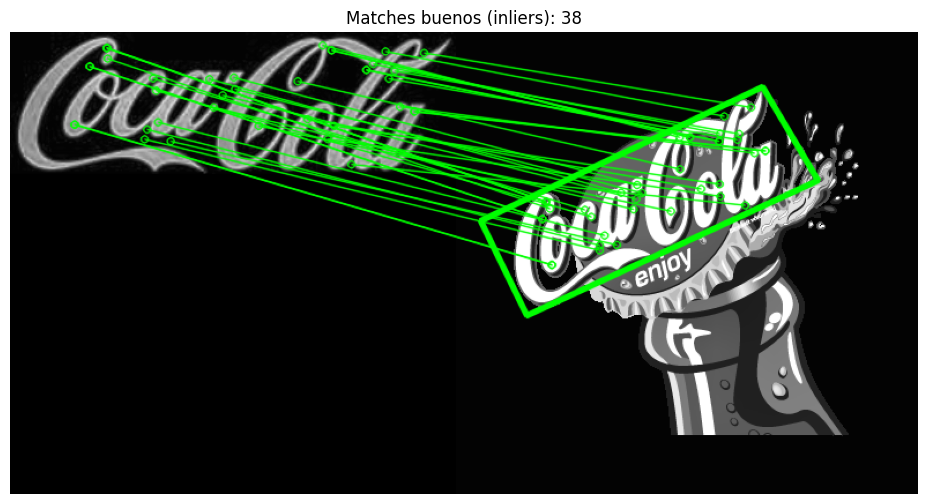

In [20]:
logo = preprocess_target("material/images/coca.png")
kp2, des2 = find_kp_and_des(logo)
match_and_show(kp1, kp2, des1, des2, logo)

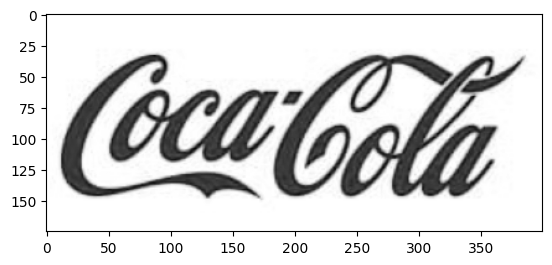

In [21]:
plt.imshow(template_raw, cmap='gray')

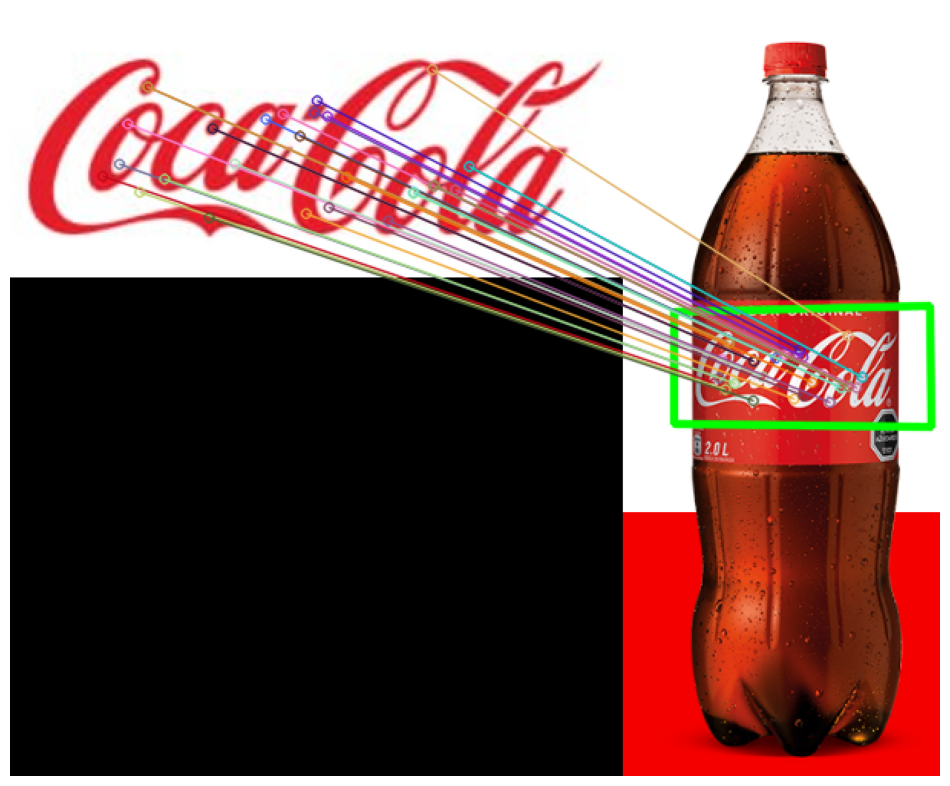

In [22]:
template_raw, template_proc, crop_xy = utils.load_and_preprocess_template("material/template/pattern.png", invert=True, equalize=True)
target_raw, target_proc = utils.preprocess_target("material/images/coca_logo_1.png", invert=False, equalize=True)

kp1, des1 = utils.find_kp_and_des(template_proc)
kp2, des2 = utils.find_kp_and_des(target_proc)

utils.match_and_show_2(template_raw, crop_xy, target_raw, kp1, des1, kp2, des2)

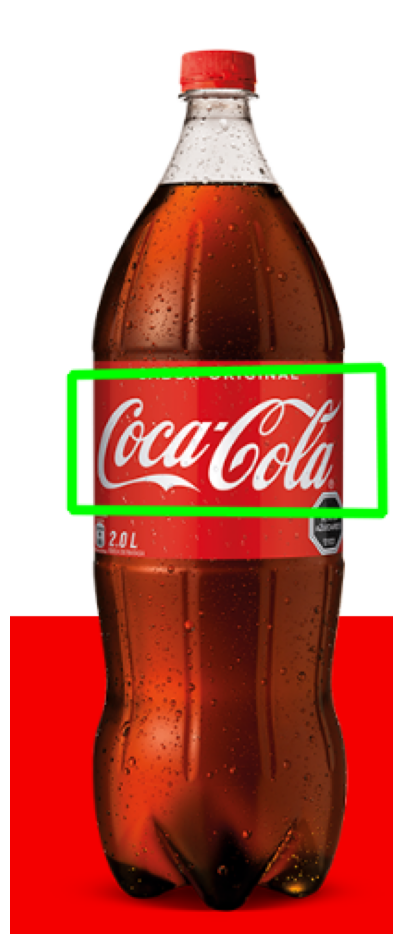

In [23]:
sv.plot_image(target_raw)


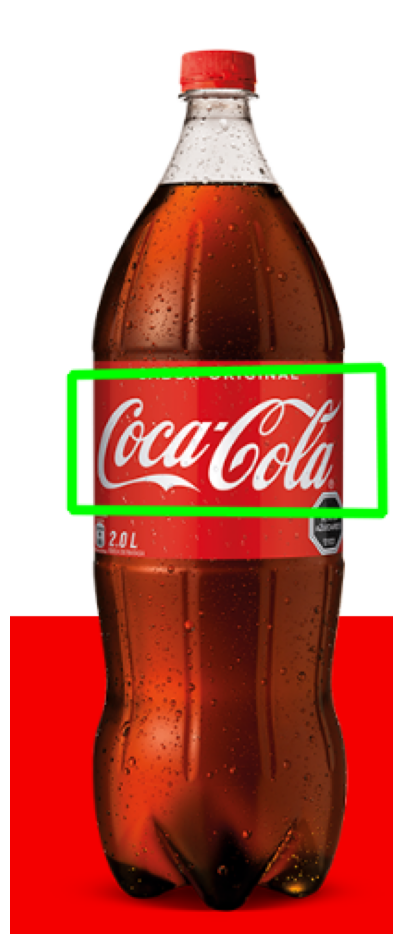

In [24]:
sv.plot_image(target_raw)